# Fase 1 — Mortalidad en PTCA: EDA + baseline

Notebook exploratorio para el **primer modelo predictivo** (ver diseño en
`docs/ml-fase0-mortalidad.md`).

- **Cohorte**: PTCA / angioplastia (`call_ptcamaster`), self-contained.
- **Target**: `fallecio = 1` si `IPfallece = 255` OR `PPfallece = 255`.
- **Features**: factores de riesgo (`FR*`) y cuadro de entrada (`CE*`) — todos
  binarios con codificación **255 = "sí"** — más edad, sexo y centro derivador.
- **Objetivo**: ¿hay señal? Baseline de regresión logística con **validación
  temporal** y métricas para datos desbalanceados (AUC-ROC, AUC-PR, Brier,
  calibración).

> Todo es iterativo: features, cutoff temporal, modelo y umbral se pueden
> ajustar. Esto es un baseline para ver si vale la pena seguir.

In [1]:
import os
import warnings

warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pymysql
from pymysql.cursors import DictCursor

# Conexión (configurable por entorno; defaults = base de producción).
DB = dict(
    host=os.getenv("INCC_MYSQL_HOST", "190.64.90.170"),
    port=int(os.getenv("INCC_MYSQL_PORT", "8809")),
    user=os.getenv("INCC_MYSQL_USER", "proyecto"),
    password=os.getenv("INCC_MYSQL_PASSWORD", "proyecto"),
    database=os.getenv("INCC_MYSQL_DB", "incc"),
)


def read_sql(sql: str) -> pd.DataFrame:
    conn = pymysql.connect(cursorclass=DictCursor, autocommit=True, read_timeout=120, **DB)
    try:
        with conn.cursor() as cur:
            cur.execute(sql)
            return pd.DataFrame(cur.fetchall())
    finally:
        conn.close()


print("Conectando a", DB["host"], ":", DB["port"], "/", DB["database"])

Conectando a 190.64.90.170 : 8809 / incc


## 1. Extracción del dataset

Una fila por PTCA realizada. Features `FR*`/`CE*` (binarias), demografía y año
(para la validación temporal).

In [2]:
# Features binarias pre-procedimiento (FR* = factores de riesgo, CE* = cuadro de entrada).
FR_FLAGS = [
    "FRhipertension", "FRtabaco", "FRdiabetes", "FRobesidad", "FRsedentario",
    "FRdislipemia", "FRenfVascular", "FRenfVascular_MMii",
    "FRenfVascular_CerebroVascular", "FRanteFam", "FRanteFamCoro", "FRanteFamMS",
]
CE_FLAGS = [
    "CEinsRenal", "CEinsRenalDialis", "CEfuncVentricular", "CEangorEstable",
    "CEangorInestable", "CEiamPrevio", "CEiamCurso", "CEinsufCardiaca", "CEarritmia",
]
FLAGS = FR_FLAGS + CE_FLAGS

flag_cols = ",\n    ".join(f"c.{col}" for col in FLAGS)
SQL = f"""
SELECT
    c.Cod                       AS cod_ptca,
    f.EdadCoo                   AS edad,
    pf.CodSexo                  AS sexo,
    f.CodSeguroCoo              AS centro,
    YEAR(f.FechaRealizado)      AS anio,
    {flag_cols},
    CASE WHEN c.IPfallece = 255 OR c.PPfallece = 255 THEN 1 ELSE 0 END AS fallecio
FROM call_ptcamaster c
JOIN flow_coordina f ON f.Cod = c.CodCoordina
LEFT JOIN pac_ficha pf ON pf.Cod = f.CodPac
WHERE f.FechaRealizado > '1900-01-01'
"""

df = read_sql(SQL)
print("Dataset:", df.shape)
df.head()

Dataset: (24313, 27)


,cod_ptca,edad,sexo,centro,anio,FRhipertension,FRtabaco,FRdiabetes,FRobesidad,FRsedentario,...,CEinsRenal,CEinsRenalDialis,CEfuncVentricular,CEangorEstable,CEangorInestable,CEiamPrevio,CEiamCurso,CEinsufCardiaca,CEarritmia,fallecio
0,73,71,0,17,1989,0,255,0,0,0,...,0,0,0,0,255,0,0,0,0,0
1,74,47,2,10,1989,0,255,0,0,0,...,0,0,0,0,255,0,0,0,0,0
2,75,53,0,5,1990,255,255,0,0,0,...,0,0,0,0,255,0,0,0,0,0
3,76,48,0,3,1989,255,255,0,0,0,...,0,0,0,0,255,0,0,0,0,0
4,77,56,0,3,1997,0,255,0,255,0,...,0,0,0,0,0,0,255,0,0,0


## 2. Limpieza y encoding

- Flags `FR*`/`CE*`: `255 = "sí"` → 1; todo lo demás (0, `1` esporádico, NULL) → 0.
- Edad: capear a `[0, 110]`; fuera de rango → NaN.
- Sexo: `0` = sin dato → NaN; el resto como categoría.
- Centro: alta cardinalidad → top 15 + `otros`.

In [3]:
# Encoding de flags clínicos: 255 = "sí".
for col in FLAGS:
    df[col] = (df[col] == 255).astype(int)

# Edad plausible.
df["edad"] = pd.to_numeric(df["edad"], errors="coerce")
df.loc[(df["edad"] < 0) | (df["edad"] > 110), "edad"] = np.nan

def as_category(series):
    """A object-string con np.nan (evita pd.NA, que rompe SimpleImputer)."""
    return series.apply(lambda v: str(int(v)) if pd.notna(v) else np.nan).astype(object)

# Sexo: 0 = sin dato -> NaN; el resto como categoría.
sexo = pd.to_numeric(df["sexo"], errors="coerce")
df["sexo"] = as_category(sexo.where(sexo != 0, np.nan))

# Centro: top 15 + "otros" (-1).
centro = pd.to_numeric(df["centro"], errors="coerce")
top_centros = centro.value_counts().nlargest(15).index
df["centro"] = as_category(centro.where(centro.isin(top_centros), other=-1))

n = len(df)
pos = int(df["fallecio"].sum())
print(f"Filas: {n:,}")
print(f"Fallecidos: {pos} ({100 * pos / n:.2f}%)  |  Vivos: {n - pos}")
df[["edad"] + FLAGS + ["fallecio"]].describe().T

Filas: 24,313
Fallecidos: 317 (1.30%)  |  Vivos: 23996


,count,mean,std,min,25%,50%,75%,max
edad,24313.0,63.010241,11.375838,15.0,55.0,63.0,71.0,103.0
FRhipertension,24313.0,0.638671,0.480396,0.0,0.0,1.0,1.0,1.0
FRtabaco,24313.0,0.555176,0.496956,0.0,0.0,1.0,1.0,1.0
FRdiabetes,24313.0,0.243738,0.429345,0.0,0.0,0.0,0.0,1.0
FRobesidad,24313.0,0.185991,0.389107,0.0,0.0,0.0,0.0,1.0
FRsedentario,24313.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0
FRdislipemia,24313.0,0.508288,0.499942,0.0,0.0,1.0,1.0,1.0
FRenfVascular,24313.0,0.045490,0.208381,0.0,0.0,0.0,0.0,1.0
FRenfVascular_MMii,24313.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0
FRenfVascular_CerebroVascular,24313.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0


## 3. EDA: prevalencias y mortalidad por año

In [4]:
# Prevalencia de cada factor de riesgo (deberían ser clínicamente plausibles).
prev = (df[FLAGS].mean() * 100).sort_values(ascending=False).round(1)
print("Prevalencia de features (% de 'sí'):")
print(prev.to_string())

# Mortalidad y volumen por año -> justifica el corte temporal.
by_year = df.groupby("anio")["fallecio"].agg(n_ptca="count", muertes="sum")
by_year["mortalidad_%"] = (by_year["muertes"] / by_year["n_ptca"] * 100).round(2)
by_year.tail(15)

Prevalencia de features (% de 'sí'):
FRhipertension                   63.9
FRtabaco                         55.5
FRdislipemia                     50.8
CEangorInestable                 50.8
FRdiabetes                       24.4
FRobesidad                       18.6
CEiamCurso                       18.0
CEiamPrevio                      16.1
CEangorEstable                   14.7
CEarritmia                        6.5
CEfuncVentricular                 6.4
CEinsufCardiaca                   5.1
FRenfVascular                     4.5
CEinsRenal                        4.1
FRanteFam                         2.8
FRanteFamCoro                     2.5
FRanteFamMS                       0.8
CEinsRenalDialis                  0.7
FRsedentario                      0.0
FRenfVascular_MMii                0.0
FRenfVascular_CerebroVascular     0.0


,n_ptca,muertes,mortalidad_%
anio,,,
2012,665,10,1.50
2013,660,9,1.36
2014,698,5,0.72
2015,709,6,0.85
2016,707,4,0.57
2017,628,6,0.96
2018,551,5,0.91
2019,619,6,0.97
2020,467,6,1.28


In [5]:
# Asociación cruda de cada feature con la muerte (tasa de mortalidad por grupo).
rows = []
for col in FLAGS:
    grp = df.groupby(col)["fallecio"].mean() * 100
    rows.append({
        "feature": col,
        "mort_si_%": round(grp.get(1, np.nan), 2),
        "mort_no_%": round(grp.get(0, np.nan), 2),
        "n_si": int((df[col] == 1).sum()),
    })
assoc = pd.DataFrame(rows)
assoc["lift"] = (assoc["mort_si_%"] / assoc["mort_no_%"]).round(2)
assoc.sort_values("lift", ascending=False)

,feature,mort_si_%,mort_no_%,n_si,lift
19,CEinsufCardiaca,7.65,0.96,1242,7.97
18,CEiamCurso,4.25,0.66,4378,6.44
14,CEfuncVentricular,4.34,1.09,1566,3.98
20,CEarritmia,3.91,1.12,1587,3.49
13,CEinsRenalDialis,4.02,1.28,174,3.14
12,CEinsRenal,2.80,1.24,999,2.26
6,FRenfVascular,1.72,1.28,1106,1.34
2,FRdiabetes,1.55,1.22,5926,1.27
3,FRobesidad,1.35,1.29,4522,1.05
0,FRhipertension,1.31,1.29,15528,1.02


## 4. Split temporal

Entrenamos con los años más antiguos y testeamos con los más recientes
(simula el uso real: predecir el futuro con datos del pasado). `TEST_FROM_YEAR`
es ajustable.

In [6]:
# Cutoff data-driven: ~último 25% de las filas (por año) va a test.
# Se puede fijar manualmente: TEST_FROM_YEAR = 2023
TEST_FROM_YEAR = int(df["anio"].quantile(0.75))

train = df[df["anio"] < TEST_FROM_YEAR].copy()
test = df[df["anio"] >= TEST_FROM_YEAR].copy()

print(f"Cutoff: test = año >= {TEST_FROM_YEAR}")
print(f"Train: {len(train):,} filas | {int(train['fallecio'].sum())} muertes "
      f"({train['fallecio'].mean() * 100:.2f}%)")
print(f"Test : {len(test):,} filas | {int(test['fallecio'].sum())} muertes "
      f"({test['fallecio'].mean() * 100:.2f}%)")
if test["fallecio"].sum() < 20:
    print("\n[!] Pocas muertes en test: las métricas serán ruidosas. Bajá TEST_FROM_YEAR.")

Cutoff: test = año >= 2015
Train: 17,713 filas | 273 muertes (1.54%)
Test : 6,600 filas | 44 muertes (0.67%)


## 5. Baseline: regresión logística

Pipeline con preprocesamiento (imputación + escala + one-hot) y
`LogisticRegression(class_weight="balanced")` para el desbalanceo. Modelo
interpretable y estándar en clínica.

In [7]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression

NUMERIC = ["edad"]
CATEG = ["sexo", "centro"]
BINARY = FLAGS
FEATURES = NUMERIC + CATEG + BINARY

X_train, y_train = train[FEATURES], train["fallecio"]
X_test, y_test = test[FEATURES], test["fallecio"]

pre = ColumnTransformer([
    ("num", Pipeline([
        ("imp", SimpleImputer(strategy="median")),
        ("sc", StandardScaler()),
    ]), NUMERIC),
    ("cat", Pipeline([
        ("imp", SimpleImputer(strategy="most_frequent")),
        ("oh", OneHotEncoder(handle_unknown="ignore")),
    ]), CATEG),
    ("bin", SimpleImputer(strategy="constant", fill_value=0), BINARY),
])

model = Pipeline([
    ("pre", pre),
    ("lr", LogisticRegression(class_weight="balanced", max_iter=2000)),
])

model.fit(X_train, y_train)
proba = model.predict_proba(X_test)[:, 1]
print("Modelo entrenado. Predicciones sobre test:", proba.shape)

Modelo entrenado. Predicciones sobre test: (6600,)


## 6. Métricas (apropiadas para datos desbalanceados)

- **AUC-ROC**: discriminación global (0.5 = azar).
- **AUC-PR**: más informativa con clases desbalanceadas; comparar contra el base rate.
- **Brier**: error de las probabilidades (menor = mejor).
- **CV AUC** en train: robustez.

In [8]:
from sklearn.metrics import (
    roc_auc_score, average_precision_score, brier_score_loss,
    confusion_matrix, classification_report, roc_curve,
)
from sklearn.model_selection import cross_val_score, StratifiedKFold

base_rate = y_test.mean()
print("=== Métricas en TEST ===")
print(f"Base rate (mortalidad test) : {base_rate * 100:.2f}%")
print(f"AUC-ROC                     : {roc_auc_score(y_test, proba):.3f}")
print(f"AUC-PR                      : {average_precision_score(y_test, proba):.3f}  "
      f"(azar = {base_rate:.3f})")
print(f"Brier score                 : {brier_score_loss(y_test, proba):.4f}")

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_auc = cross_val_score(model, X_train, y_train, cv=cv, scoring="roc_auc")
print(f"\nCV AUC-ROC (train, 5-fold)  : {cv_auc.round(3)}  media {cv_auc.mean():.3f}")

# Umbral por índice de Youden (maximiza sensibilidad + especificidad).
fpr, tpr, thr = roc_curve(y_test, proba)
best_thr = thr[np.argmax(tpr - fpr)]
pred = (proba >= best_thr).astype(int)
print(f"\nUmbral óptimo (Youden)      : {best_thr:.3f}")
print("\nMatriz de confusión [fila=real, col=pred]:")
print(confusion_matrix(y_test, pred))
print("\n", classification_report(y_test, pred, digits=3))

=== Métricas en TEST ===
Base rate (mortalidad test) : 0.67%
AUC-ROC                     : 0.815
AUC-PR                      : 0.093  (azar = 0.007)
Brier score                 : 0.1531



CV AUC-ROC (train, 5-fold)  : [0.838 0.786 0.838 0.823 0.818]  media 0.821

Umbral óptimo (Youden)      : 0.443

Matriz de confusión [fila=real, col=pred]:
[[4853 1703]
 [   9   35]]

               precision    recall  f1-score   support

           0      0.998     0.740     0.850      6556
           1      0.020     0.795     0.039        44

    accuracy                          0.741      6600
   macro avg      0.509     0.768     0.445      6600
weighted avg      0.992     0.741     0.845      6600



## 7. Curvas: ROC, Precision-Recall y calibración

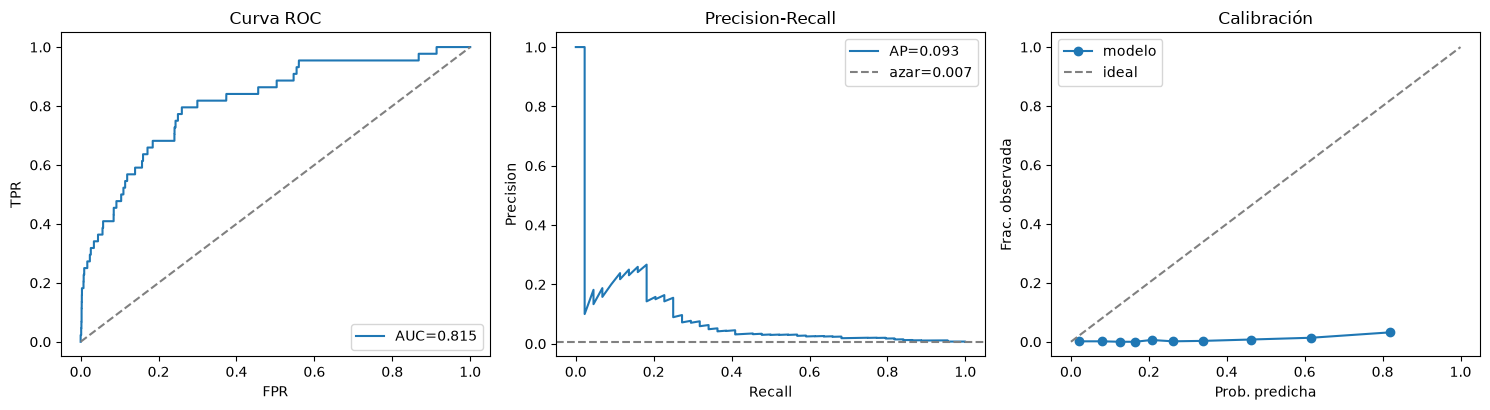

In [9]:
from sklearn.metrics import precision_recall_curve
from sklearn.calibration import calibration_curve

fig, ax = plt.subplots(1, 3, figsize=(15, 4.2))

# ROC
ax[0].plot(fpr, tpr, label=f"AUC={roc_auc_score(y_test, proba):.3f}")
ax[0].plot([0, 1], [0, 1], "--", color="gray")
ax[0].set(xlabel="FPR", ylabel="TPR", title="Curva ROC")
ax[0].legend(loc="lower right")

# Precision-Recall
prec, rec, _ = precision_recall_curve(y_test, proba)
ax[1].plot(rec, prec, label=f"AP={average_precision_score(y_test, proba):.3f}")
ax[1].axhline(base_rate, ls="--", color="gray", label=f"azar={base_rate:.3f}")
ax[1].set(xlabel="Recall", ylabel="Precision", title="Precision-Recall")
ax[1].legend(loc="upper right")

# Calibración
frac_pos, mean_pred = calibration_curve(y_test, proba, n_bins=10, strategy="quantile")
ax[2].plot(mean_pred, frac_pos, "o-", label="modelo")
ax[2].plot([0, 1], [0, 1], "--", color="gray", label="ideal")
ax[2].set(xlabel="Prob. predicha", ylabel="Frac. observada", title="Calibración")
ax[2].legend(loc="upper left")

plt.tight_layout()
plt.show()

## 8. Interpretabilidad: coeficientes / odds ratios

Odds ratio > 1 → el factor **aumenta** el riesgo; < 1 → lo **reduce**. Es la
lectura clínica natural de una regresión logística.

In [10]:
feat_names = model.named_steps["pre"].get_feature_names_out()
coefs = model.named_steps["lr"].coef_[0]

imp = pd.DataFrame({"feature": feat_names, "coef": coefs})
imp["odds_ratio"] = np.exp(imp["coef"]).round(3)
imp["abs_coef"] = imp["coef"].abs()
imp = imp.sort_values("abs_coef", ascending=False).drop(columns="abs_coef")
imp.head(20).reset_index(drop=True)

,feature,coef,odds_ratio
0,bin__CEiamCurso,2.429055,11.348
1,bin__FRanteFam,-1.908786,0.148
2,bin__CEinsufCardiaca,1.876184,6.529
3,cat__centro_12,-1.490655,0.225
4,bin__FRanteFamCoro,-1.460138,0.232
5,cat__centro_5,-1.247572,0.287
6,cat__centro_35,-0.962639,0.382
7,bin__CEfuncVentricular,0.888003,2.430
8,bin__CEangorInestable,0.840593,2.318
9,bin__FRanteFamMS,-0.748301,0.473


## 9. Conclusiones (resultados de la corrida)

**Hay señal.** El baseline discrimina bien:

- **AUC-ROC ≈ 0.82** en validación temporal (test = año ≥ 2015) y **CV AUC ≈ 0.82**
  en train (5-fold) → consistente y robusto, muy por encima del azar (0.5).
- **AUC-PR 0.093 vs 0.007** de azar → ~13× mejor que aleatorio (bajo en absoluto
  por la baja prevalencia, pero claramente informativo).
- Los factores con mayor riesgo crudo tienen **sentido clínico**: insuficiencia
  cardíaca (lift ×8), IAM en curso (×6.4), disfunción ventricular (×4), arritmia
  (×3.5), insuf. renal en diálisis (×3). Coherente con el conocimiento médico.

**Limitaciones detectadas (a corregir en la próxima iteración):**

1. **Outcome sin cargar en años recientes**: 2024–2026 muestran 0.00% de
   mortalidad (imposible) → los campos `IPfallece`/`PPfallece` aún no se
   completaron. Esas filas entran como negativos falsos (ruido de etiqueta).
   **Acción**: restringir el dataset a `anio <= 2023` (o al último año con
   outcomes cargados).
2. **Features vacías**: `FRsedentario`, `FRenfVascular_MMii`,
   `FRenfVascular_CerebroVascular` son 100% 0 → quitarlas.
3. **Calibración pobre** (Brier alto): esperable con `class_weight="balanced"`;
   las probabilidades están infladas. Se resuelve con `CalibratedClassifierCV`.

**Próximos pasos (Fase 2/3)**: aplicar las correcciones 1–3, probar gradient
boosting (`xgboost`), agregar SHAP, y productivizar en
`scripts/train_ptca_mortality.py` + `app/services/ml_service.py` + endpoint.